
# HOUSE PRICE PREDICTION


## IMPORTING REQUIRED LIBRARIES

In [46]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import OneHotEncoder


## LOADING DATASET

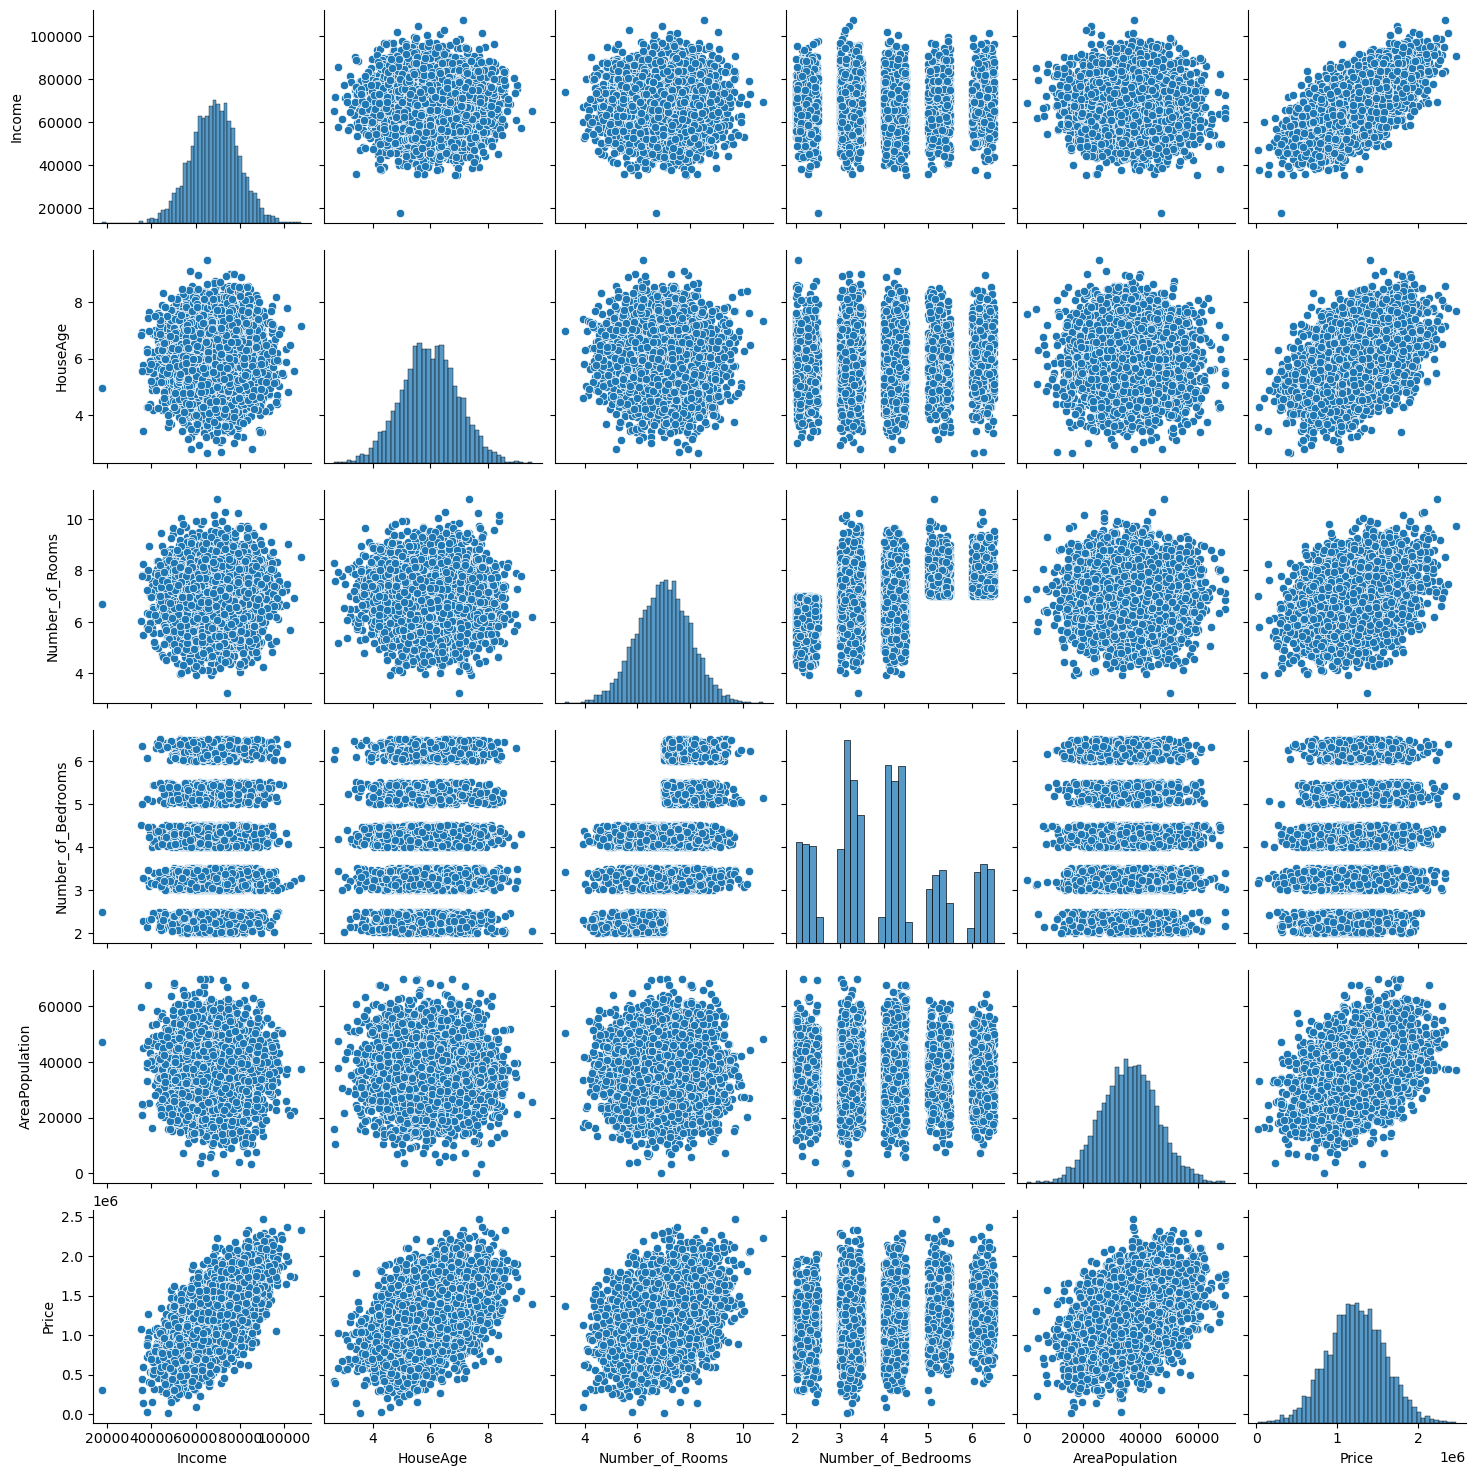

In [47]:
data=pd.read_csv(r"C:\Users\vvans\Downloads\USA_Housing.csv")
sns.pairplot(data)
plt.show()

In [48]:
data.head()

,Income,HouseAge,Number_of_Rooms,Number_of_Bedrooms,AreaPopulation,Price,Address
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,"208 Michael Ferry Apt. 674\nLaurabury, NE 3701..."
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,"188 Johnson Views Suite 079\nLake Kathleen, CA..."
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,"9127 Elizabeth Stravenue\nDanieltown, WI 06482..."
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,USS Barnett\nFPO AP 44820
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,USNS Raymond\nFPO AE 09386


## CHECK FOR MISSED DATA

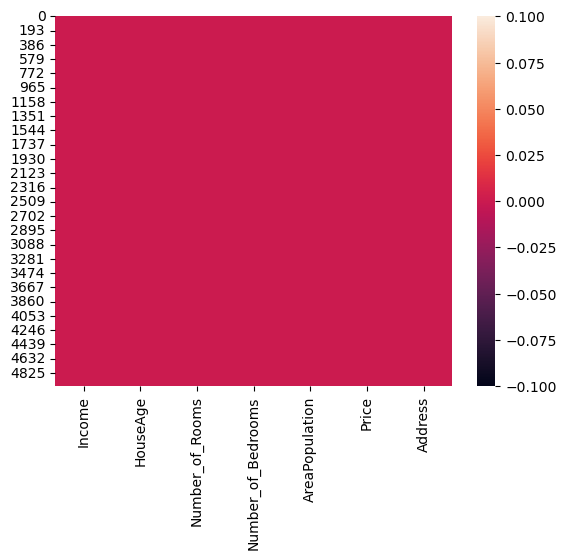

In [49]:
sns.heatmap(data.isnull())
plt.show()

## Encode location using OneHotEncoder


In [50]:
encoder = OneHotEncoder(handle_unknown='ignore')
encoded_location = encoder.fit_transform(data[["Address"]]).toarray()
location_df = pd.DataFrame(encoded_location, columns=encoder.get_feature_names_out(["Address"]))
location_df

,"Address_000 Adkins Crescent\nSouth Teresa, AS 49642-1348","Address_000 Todd Pines\nAshleyberg, KY 90207-1179","Address_001 Steve Plaza\nJessicastad, UT 25190","Address_0010 Gregory Loaf\nSouth Ericfort, VA 34651-0718","Address_00149 Raymond Knolls\nNew Jason, UT 75026","Address_002 Katherine Flat\nHartmanland, AZ 37973-3049","Address_0022 Young Rest\nLake Kevin, CA 25438-1821","Address_0029 Melinda Neck Apt. 591\nLake Gregoryshire, HI 60267","Address_003 Erica Passage Apt. 274\nEast Ritaton, KS 97261-8617","Address_003 Fernando Gateway Suite 145\nEast Danielshire, GA 76041",...,Address_Unit 9446 Box 0958\nDPO AE 97025,Address_Unit 9463 Box 0963\nDPO AE 49984-2796,Address_Unit 9494 Box 2307\nDPO AE 58622,Address_Unit 9664 Box 1605\nDPO AA 30902,Address_Unit 9732 Box 1846\nDPO AE 69898-3304,Address_Unit 9774 Box 4511\nDPO AE 44963,Address_Unit 9778 Box 2114\nDPO AP 59374,Address_Unit 9785 Box 0790\nDPO AP 60371-0797,Address_Unit 9831 Box 7128\nDPO AA 54705,Address_Unit 9871 Box 9037\nDPO AP 37275-9289
0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Merge encoded data

In [51]:
final_data = pd.concat([data.drop("Address", axis=1), location_df],axis=1)
final_data

,Income,HouseAge,Number_of_Rooms,Number_of_Bedrooms,AreaPopulation,Price,"Address_000 Adkins Crescent\nSouth Teresa, AS 49642-1348","Address_000 Todd Pines\nAshleyberg, KY 90207-1179","Address_001 Steve Plaza\nJessicastad, UT 25190","Address_0010 Gregory Loaf\nSouth Ericfort, VA 34651-0718",...,Address_Unit 9446 Box 0958\nDPO AE 97025,Address_Unit 9463 Box 0963\nDPO AE 49984-2796,Address_Unit 9494 Box 2307\nDPO AE 58622,Address_Unit 9664 Box 1605\nDPO AA 30902,Address_Unit 9732 Box 1846\nDPO AE 69898-3304,Address_Unit 9774 Box 4511\nDPO AE 44963,Address_Unit 9778 Box 2114\nDPO AP 59374,Address_Unit 9785 Box 0790\nDPO AP 60371-0797,Address_Unit 9831 Box 7128\nDPO AA 54705,Address_Unit 9871 Box 9037\nDPO AP 37275-9289
0,79545.45857,5.682861,7.009188,4.09,23086.80050,1.059034e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,79248.64245,6.002900,6.730821,3.09,40173.07217,1.505891e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,61287.06718,5.865890,8.512727,5.13,36882.15940,1.058988e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,63345.24005,7.188236,5.586729,3.26,34310.24283,1.260617e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,59982.19723,5.040555,7.839388,4.23,26354.10947,6.309435e+05,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,60567.94414,7.830362,6.137356,3.46,22837.36103,1.060194e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4996,78491.27543,6.999135,6.576763,4.02,25616.11549,1.482618e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4997,63390.68689,7.250591,4.805081,2.13,33266.14549,1.030730e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4998,68001.33124,5.534388,7.130144,5.44,42625.62016,1.198657e+06,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## TEST TRAIN SPLIT

In [52]:
x=final_data.drop("Price",axis=1)
y=final_data["Price"]

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)  

##  TRAINING AND PREDICTION

In [53]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [61]:
predictions=model.predict(x_test)
predictions[0].item()

1308553.829079399

## EVALUATION

In [55]:
error=np.sqrt(mean_absolute_error(y_test,predictions))
error

np.float64(284.3977508217068)

In [56]:
model.score(x_test,y_test)*100

91.79914220389264

## SAVING DATA

In [57]:
joblib.dump(model,"model.sav")

['model.sav']

In [58]:
joblib.dump(encoder,"encoder.sav")

['encoder.sav']